In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("..\Datasets\California Housing Dataset-Regression Dataset\housing.csv")
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [62]:
df.dropna(subset=['total_bedrooms'],inplace=True)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [63]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [64]:
value = df[['median_income','median_house_value']]
value

,median_income,median_house_value
0,8.3252,452600.0
1,8.3014,358500.0
2,7.2574,352100.0
3,5.6431,341300.0
4,3.8462,342200.0
...,...,...
20635,1.5603,78100.0
20636,2.5568,77100.0
20637,1.7000,92300.0
20638,1.8672,84700.0


<function matplotlib.pyplot.show(close=None, block=None)>

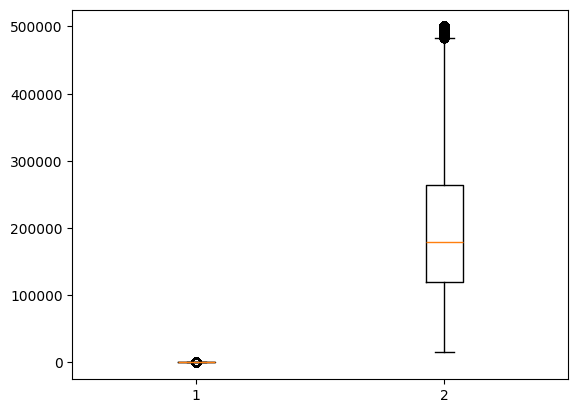

In [65]:
plt.boxplot(value)
plt.show

In [66]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0,1,0,0,0


<Axes: >

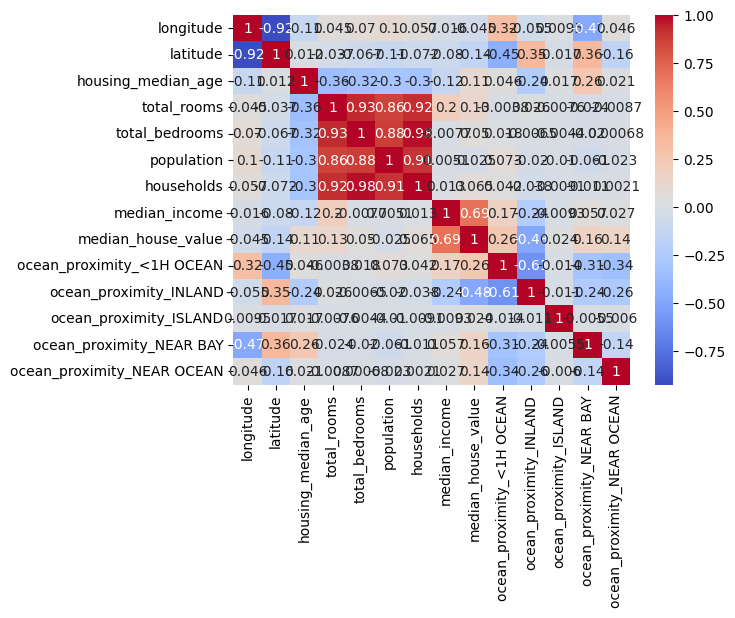

In [67]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [68]:
y = df['median_house_value']
x = df.drop(['median_house_value'], axis=1)

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [70]:
x_train.shape

(16346, 13)

In [71]:
x_test.shape

(4087, 13)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [73]:
X_train

array([[-1.10651441,  0.78620804, -1.16206244, ..., -0.01354861,
        -0.35636982, -0.38540693],
       [-0.02467137,  0.46787317,  0.34865716, ..., -0.01354861,
        -0.35636982, -0.38540693],
       [ 0.75804456, -0.71183841, -0.2874353 , ..., -0.01354861,
        -0.35636982, -0.38540693],
       ...,
       [ 0.5785683 , -0.76333376,  1.06426118, ..., -0.01354861,
        -0.35636982, -0.38540693],
       [-1.22616525,  0.90324292, -1.32108555, ..., -0.01354861,
         2.80607376, -0.38540693],
       [-1.42059787,  0.97814524,  1.85937675, ..., -0.01354861,
         2.80607376, -0.38540693]], shape=(16346, 13))

In [74]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R² Score
r2 = r2_score(y_test, y_pred)

# 5. Adjusted R² Score
n = X_test.shape[0]      # Number of samples
p = X_test.shape[1]      # Number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Print Results
print(f"MAE         : {mae:.4f}")
print(f"MSE         : {mse:.4f}")
print(f"RMSE        : {rmse:.4f}")
print(f"R² Score    : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")

MAE         : 50413.4333
MSE         : 4802173538.6042
RMSE        : 69297.7167
R² Score    : 0.6488
Adjusted R² : 0.6477


In [77]:
data = [[-122.22,37.86,18.0,1467.0,374.0,356.0,330.0,7.2574,0,0,1,0,0]]
data_scaled = scaler.fit_transform(data)
prediction = model.predict(data_scaled)
print(prediction)

[206644.40009788]
